<a href="https://colab.research.google.com/github/offjisung-alt/MachineLearning/blob/main/3_%ED%9A%8C%EA%B7%80%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**3-1. K-최근접 이웃 회귀**

In [ ]:
import numpy as np

#데이터 불러오기
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

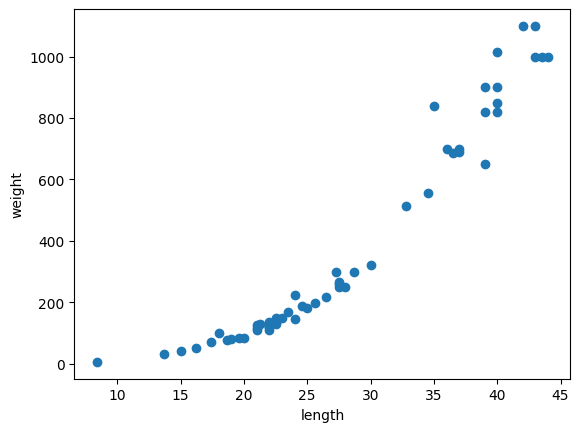

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

KNeighborsRegressor()

### 결정계수 ($R^2$)

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

- $y_i$ : 실제 타깃값
- $\hat{y}_i$ : 예측값
- $\bar{y}$ : 타깃값의 평균

In [ ]:
from sklearn.metrics import mean_absolute_error

#테스트 세트에 대한 예측
test_prediction = knr.predict(test_input)

#테스트 세트에 대한 평균 절댓값 오차 계산
mae = mean_absolute_error(test_target, test_prediction)

print(mae)

19.157142857142862


### 과소적합 (Underfitting)

과소적합은 모델이 데이터의 중요한 패턴을 충분히 학습하지 못한 상태를 의미한다.
모델이 너무 단순하거나 학습이 부족할 때 발생하며, 훈련 데이터와 테스트 데이터 모두에서 성능이 낮게 나타난다.

특징:
- 훈련 데이터 성능이 낮음
- 테스트 데이터 성능도 낮음
- 높은 편향(High Bias)을 가짐

예시:
- 복잡한 곡선 형태의 데이터를 직선으로만 예측하는 경우

---

### 과대적합 (Overfitting)

과대적합은 모델이 훈련 데이터의 패턴뿐만 아니라 노이즈까지 학습한 상태를 의미한다.
훈련 데이터에서는 매우 높은 성능을 보이지만, 새로운 데이터에 대해서는 성능이 크게 떨어진다.

특징:
- 훈련 데이터 성능이 매우 높음
- 테스트 데이터 성능이 낮음
- 높은 분산(High Variance)을 가짐

예시:
- 데이터 포인트를 모두 통과하도록 지나치게 복잡한 곡선을 학습한 경우

---

### 적절한 학습 (Good Fit)

적절한 학습은 데이터의 핵심 패턴을 잘 학습하면서도 새로운 데이터에 대해 좋은 일반화 성능을 보이는 상태를 의미한다.

특징:
- 훈련 데이터와 테스트 데이터 모두 높은 성능
- 과소적합과 과대적합 사이의 균형
- 좋은 일반화 성능 보유

#**3-2. 선형회귀**

In [ ]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


In [ ]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors = 3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [ ]:
print(knr.predict([[50]]))

[1033.33333333]


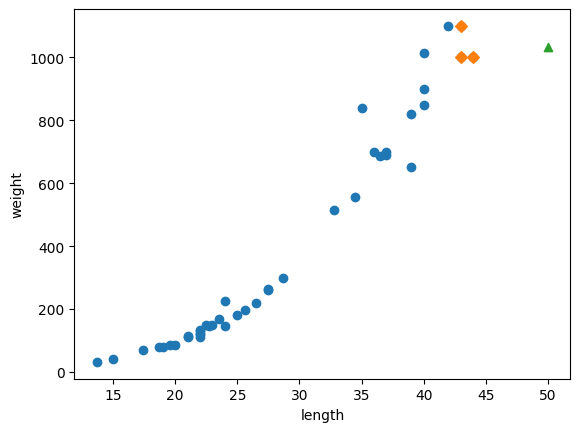

In [ ]:
import matplotlib.pyplot as plt

distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(50, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

K-최근접 회귀의 경우 주변 데이터의 평균값들로 구하기 때문에 예측에 용이하지 못한다.
이것의 대안으로 나온 것이
#**선형회귀**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.predict([[50]]))
print(lr.coef_, lr.intercept_) # coef의 경우 직선의 기울기, intercept의 경우 절편

[1241.83860323]
[39.01714496] -709.0186449535477


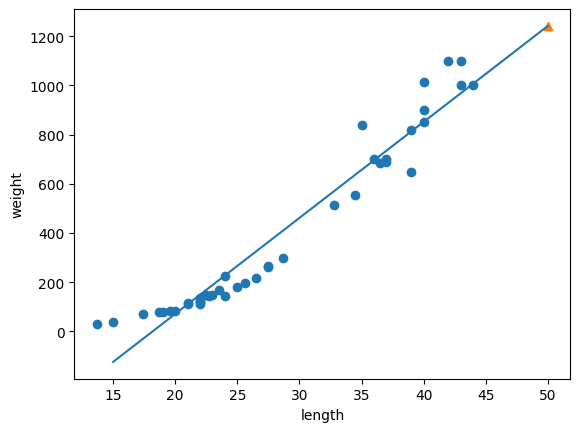

In [ ]:
plt.scatter(train_input, train_target)
plt.plot([15, 50], [15*lr.coef_ +lr.intercept_, 50*lr.coef_ + lr.intercept_])

plt.scatter(50, 1241.8, marker = '^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

위의 산점도를 보면 직선이 아닌 곡선이라는 것을 직감적으로 눈치챌 수 있다.

In [ ]:
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [ ]:
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


### 다항 회귀 (Polynomial Regression)

기본 선형 회귀는 다음과 같은 직선 형태의 관계만 학습할 수 있다.

$$
y = ax + b
$$

하지만 물고기의 길이와 무게처럼 실제 데이터는 곡선 형태를 가지는 경우가 많다. 이를 해결하기 위해 기존 특성 $x$에 제곱 특성 $x^2$를 추가하였다.

```python
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

### `plt.plot()` 함수

`plt.plot()`은 Matplotlib에서 선 그래프(Line Plot)를 그릴 때 사용하는 함수이다.

기본 형식은 다음과 같다.

```python
plt.plot(x, y)

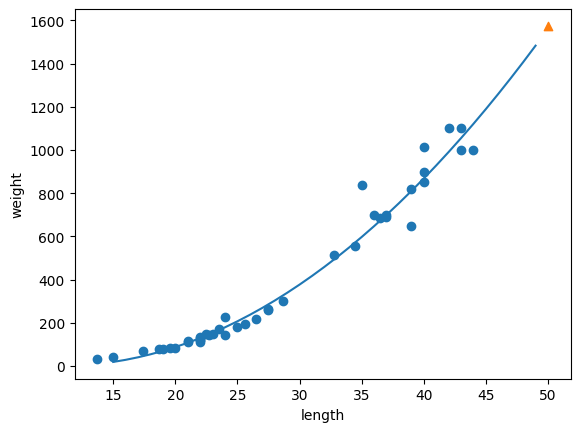

In [ ]:
point = np.arange(15, 50)
plt.scatter(train_input, train_target)

plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)

plt.scatter(50, 1574, marker = '^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

#**3-3. 특성 공학과 규제**

# 다중 회귀 (Multiple Regression)

다중 회귀는 **여러 개의 특성(입력 변수)을 이용하여 하나의 값을 예측하는 회귀 모델**이다.

회귀식:

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

- $y$ : 예측값
- $x_1, x_2, ..., x_n$ : 입력 특성
- $\beta_0$ : 절편
- $\beta_1, \beta_2, ..., \beta_n$ : 회귀 계수

예를 들어 생선의 무게를 예측할 때 길이, 높이, 두께를 함께 사용할 수 있다.

---

# 특성 공학 (Feature Engineering)

특성 공학은 **기존 특성을 이용해 새로운 특성을 만드는 과정**이다.

예를 들어 길이 $x$만 있을 때

$$
x \rightarrow (x,\; x^2)
$$

와 같이 제곱 특성을 추가할 수 있다.

또는 두 특성 $x_1, x_2$가 있을 때

$$
(x_1,\; x_2,\; x_1^2,\; x_2^2,\; x_1x_2)
$$

와 같이 새로운 특성을 생성할 수 있다.

### 목적
- 데이터의 숨겨진 패턴 표현
- 모델 성능 향상
- 비선형 관계 학습 가능

---

# 다중 회귀와 특성 공학

특성 공학으로 특성을 추가하면 다중 회귀가 수행된다.

예를 들어

$$
y = \beta_0 + \beta_1x + \beta_2x^2
$$

와 같은 모델을 만들 수 있다.

즉, **새로운 특성을 만들어 다중 회귀의 입력으로 사용하는 과정이 특성 공학이다.**

In [ ]:
import pandas as pd
df = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [ ]:
import numpy as np
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)


In [ ]:
#사이킷런의 변환기
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures()
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]


In [ ]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)
print(poly.get_feature_names_out())
test_poly = poly.transform(test_input)

(42, 9)
['x0' 'x1' 'x2' 'x0^2' 'x0 x1' 'x0 x2' 'x1^2' 'x1 x2' 'x2^2']


# PolynomialFeatures 이해하기

## 1. PolynomialFeatures란?

`PolynomialFeatures`는 기존 특성(Feature)으로부터 제곱항, 곱셈항 등의 새로운 특성을 자동으로 생성하는 클래스이다.

예를 들어 입력 데이터가

```python
X = [[2, 3]]
```

이라면

- $x_1 = 2$
- $x_2 = 3$

이다.

`PolynomialFeatures`를 적용하면

$$
[x_1,\;x_2,\;x_1^2,\;x_1x_2,\;x_2^2]
$$

가 생성된다.

숫자를 대입하면

$$
[2,\;3,\;4,\;6,\;9]
$$

가 된다.

---

## 2. include_bias=False

```python
poly = PolynomialFeatures(include_bias=False)
```

기본적으로 `PolynomialFeatures`는 맨 앞에 1을 추가한다.

$$
[1,\;x_1,\;x_2,\;x_1^2,\;x_1x_2,\;x_2^2]
$$

하지만

```python
include_bias=False
```

를 사용하면

$$
[x_1,\;x_2,\;x_1^2,\;x_1x_2,\;x_2^2]
$$

만 생성된다.

선형회귀가 절편(Intercept)을 따로 학습하므로 보통 `False`를 사용한다.

---

## 3. fit()

```python
poly.fit(train_input)
```

`fit()`은 실제 학습을 수행하는 것이 아니다.

입력 데이터에 특성이 몇 개 있는지 확인하는 과정이다.

예를 들어

```python
train_input.shape
```

가

```python
(42, 2)
```

라면

- 샘플 수 : 42개
- 특성 수 : 2개

라는 정보를 저장한다.

---

## 4. transform()

```python
train_poly = poly.transform(train_input)
```

`transform()`은 새로운 특성을 생성한다.

예를 들어

```python
[2, 3]
```

이 입력되면

$$
[2,\;3,\;4,\;6,\;9]
$$

로 변환된다.

즉,

$$
[x_1,\;x_2]
\rightarrow
[x_1,\;x_2,\;x_1^2,\;x_1x_2,\;x_2^2]
$$

가 된다.

---

## 5. train_poly.shape

```python
print(train_poly.shape)
```

원래 데이터가

```python
(42, 2)
```

였다면

생성된 특성은

- $x_1$
- $x_2$
- $x_1^2$
- $x_1x_2$
- $x_2^2$

총 5개가 된다.

따라서

```python
(42, 5)
```

가 출력된다.

---

## 6. get_feature_names_out()

```python
print(poly.get_feature_names_out())
```

생성된 특성 이름을 출력한다.

예를 들어

```python
['x0', 'x1']
```

이라는 입력 특성이 있으면

```python
['x0'
 'x1'
 'x0^2'
 'x0 x1'
 'x1^2']
```

가 출력된다.

의미는 다음과 같다.

- x0 : 첫 번째 특성
- x1 : 두 번째 특성
- x0² : 첫 번째 특성의 제곱
- x0×x1 : 두 특성의 곱
- x1² : 두 번째 특성의 제곱

---

## 7. 테스트 데이터는 왜 fit하지 않을까?

```python
test_poly = poly.transform(test_input)
```

테스트 데이터는 `fit()`을 수행하지 않는다.

학습 데이터 기준으로 생성한 특성을 동일하게 적용해야 하기 때문이다.

올바른 방법은

```python
poly.fit(train_input)

train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
```

이다.

---

## 전체 흐름

원본 데이터

$$
[길이,\;높이]
$$

↓

PolynomialFeatures 적용

↓

$$
[길이,\;높이,\;길이^2,\;길이 \times 높이,\;높이^2]
$$

↓

새로운 특성 생성

↓

다중 회귀 모델 학습

즉, `PolynomialFeatures`는 특성 공학(Feature Engineering)을 자동으로 수행하여 더 복잡한 패턴을 학습할 수 있도록 도와준다.

In [ ]:
#다중 회귀모델 훈련하기
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9903183436982125
0.9714559911594111


In [ ]:
#파라미터 수를 증가 -> 과대적합 가능성 커짐
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)



lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

(42, 55)
0.9999999999996433
-144.40579436844948


# 규제(Regularization)

## 규제란?

규제(Regularization)는 모델이 훈련 데이터에 너무 과하게 맞춰지는 **과대적합(Overfitting)** 을 방지하기 위한 기법이다.

회귀 모델에서 특성이 많아지면 회귀 계수(가중치)가 매우 커질 수 있는데, 이는 새로운 데이터에 대한 예측 성능을 떨어뜨릴 수 있다.

규제는 회귀 계수의 크기에 패널티를 부여하여 모델을 단순하게 만든다.

---

## 규제가 필요한 이유

과대적합된 모델

- 훈련 데이터 성능 : 매우 높음
- 테스트 데이터 성능 : 낮음

규제를 적용한 모델

- 훈련 데이터 성능 : 약간 감소
- 테스트 데이터 성능 : 향상

즉, 일반화 성능을 높이기 위해 사용한다.

---

# 릿지 회귀 (Ridge Regression)

릿지 회귀는 회귀 계수의 제곱합에 패널티를 부여하는 방법이다.

목적 함수

$$
Loss = RSS + \lambda \sum_{i=1}^{n}\beta_i^2
$$

여기서

- RSS : 잔차 제곱합
- $\lambda$ : 규제 강도
- $\beta_i$ : 회귀 계수

---

## 특징

- 큰 계수를 작게 만든다.
- 모든 특성을 유지한다.
- 계수를 0으로 만들지는 않는다.
- 특성이 많은 경우 안정적인 성능을 보인다.

예시

원래 계수

$$
[10,\;8,\;5,\;3]
$$

릿지 적용 후

$$
[6,\;5,\;3,\;2]
$$

모든 계수가 줄어들지만 제거되지는 않는다.

---

# 라쏘 회귀 (Lasso Regression)

라쏘 회귀는 회귀 계수의 절댓값 합에 패널티를 부여하는 방법이다.

목적 함수

$$
Loss = RSS + \lambda \sum_{i=1}^{n}|\beta_i|
$$

---

## 특징

- 중요하지 않은 특성의 계수를 0으로 만든다.
- 자동으로 특성 선택(Feature Selection)을 수행한다.
- 불필요한 특성을 제거할 수 있다.

예시

원래 계수

$$
[10,\;8,\;5,\;3]
$$

라쏘 적용 후

$$
[7,\;4,\;0,\;0]
$$

일부 계수가 0이 되어 해당 특성이 제거된다.

---

# 릿지와 라쏘 비교

| 구분 | 릿지(Ridge) | 라쏘(Lasso) |
|--------|--------|--------|
| 규제 방식 | L2 규제 | L1 규제 |
| 패널티 | $\sum \beta_i^2$ | $\sum |\beta_i|$ |
| 계수 감소 | O | O |
| 계수를 0으로 만듦 | X | O |
| 특성 선택 | X | O |
| 사용 목적 | 과대적합 완화 | 과대적합 완화 + 특성 선택 |

---

# 핵심 정리

- 규제는 과대적합을 방지하기 위한 기법이다.
- 릿지 회귀는 계수를 작게 만들지만 0으로 만들지는 않는다.
- 라쏘 회귀는 일부 계수를 0으로 만들어 특성을 제거한다.
- 특성이 많을 때는 릿지와 라쏘를 사용하여 일반화 성능을 향상시킬 수 있다.

In [ ]:
#주의할 점!!!!!!!
#꼭 훈련 세트로 학습한 변환기를 사용해 테스트 세트까지 반환해야 한다!!!!!

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

In [ ]:
from sklearn.linear_model import Ridge

#alpha 매개변수로 규제의 강도를 조절할 수 있다.
#alpha 값이 크면 규제 강도가 세지므로 계수 값을 더 줄이고 과소 적합될 수 있도록 유도한다.
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9896101671037343
0.9790693977615387


Text(0, 0.5, 'R^2')

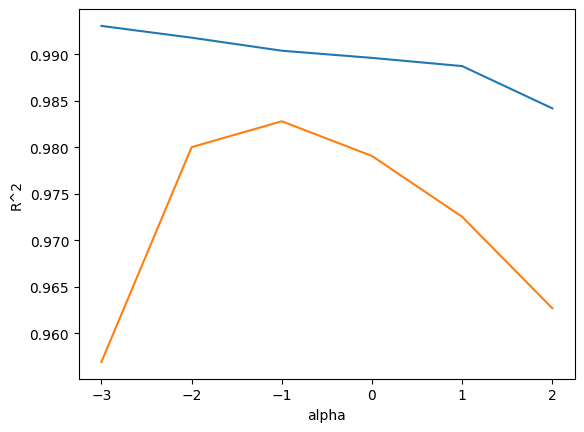

In [ ]:
#적절한 alpha 값을 찾는 방법
import matplotlib.pyplot as plt
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
  ridge = Ridge(alpha = alpha)
  ridge.fit(train_scaled, train_target)
  train_score.append(ridge.score(train_scaled, train_target))
  test_score.append(ridge.score(test_scaled, test_target))

#그래프로 확인
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')

그래프를 확인해 보면 alpha 값이 -1 즉 0.1일 때 균형적인 모델임을 예측할 수 있다.

In [ ]:
ridge = Ridge(alpha = 0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570367
0.9827976465386928


0.989789897208096
0.9800593698421883


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


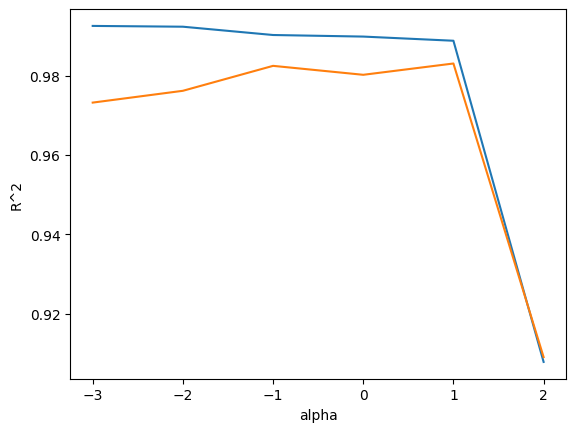

0.9888067471131867
0.9824470598706695


In [ ]:
#라쏘 회귀
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
  lasso = Lasso(alpha = alpha, max_iter=10000)
  lasso.fit(train_scaled, train_target)
  train_score.append(lasso.score(train_scaled, train_target))
  test_score.append(lasso.score(test_scaled, test_target))

plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

lasso = Lasso(alpha = 10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))


In [ ]:
lasso = Lasso(alpha = 10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))
print(np.sum(lasso.coef_ == 0))

0.9888067471131867
0.9824470598706695
40
